In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('engine_data.csv')
data.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [3]:
data.isnull().sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [4]:
data.duplicated().sum()

0

In [5]:
data.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


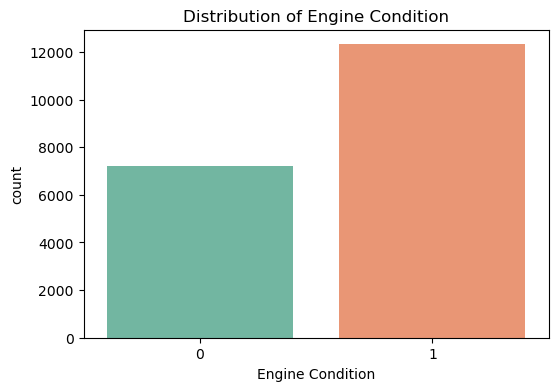

In [6]:
# Exploratory Data Analysis (EDA)
# 1. Distribution of the target variable ("Engine Condition")
plt.figure(figsize=(6, 4))
sns.countplot(x='Engine Condition', data=data, palette='Set2')
plt.title('Distribution of Engine Condition')
plt.show()

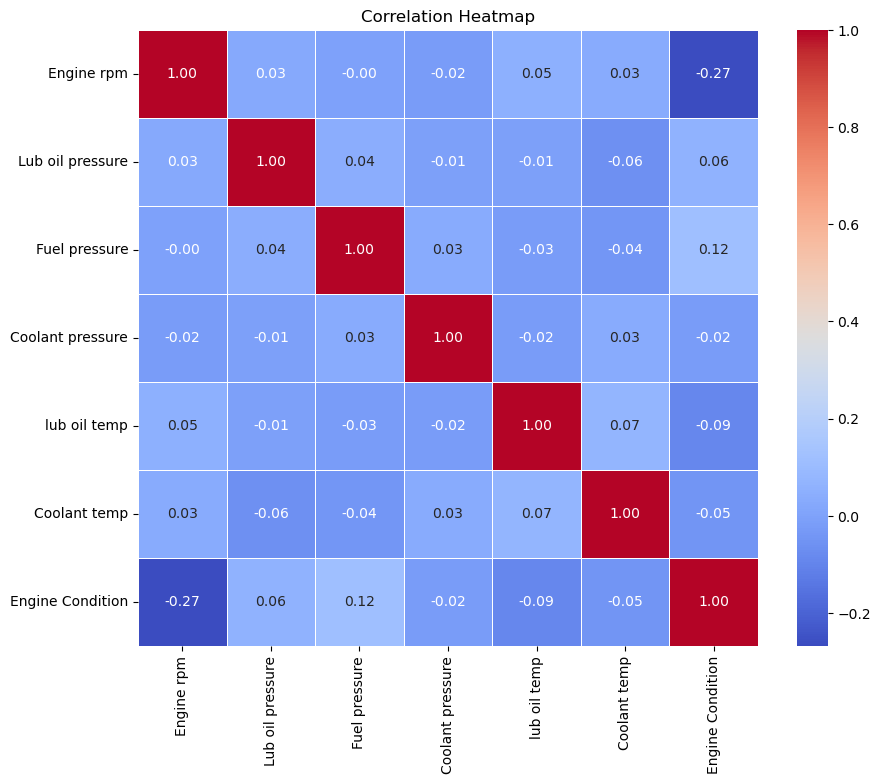

In [7]:
# 2. Correlation heatmap
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

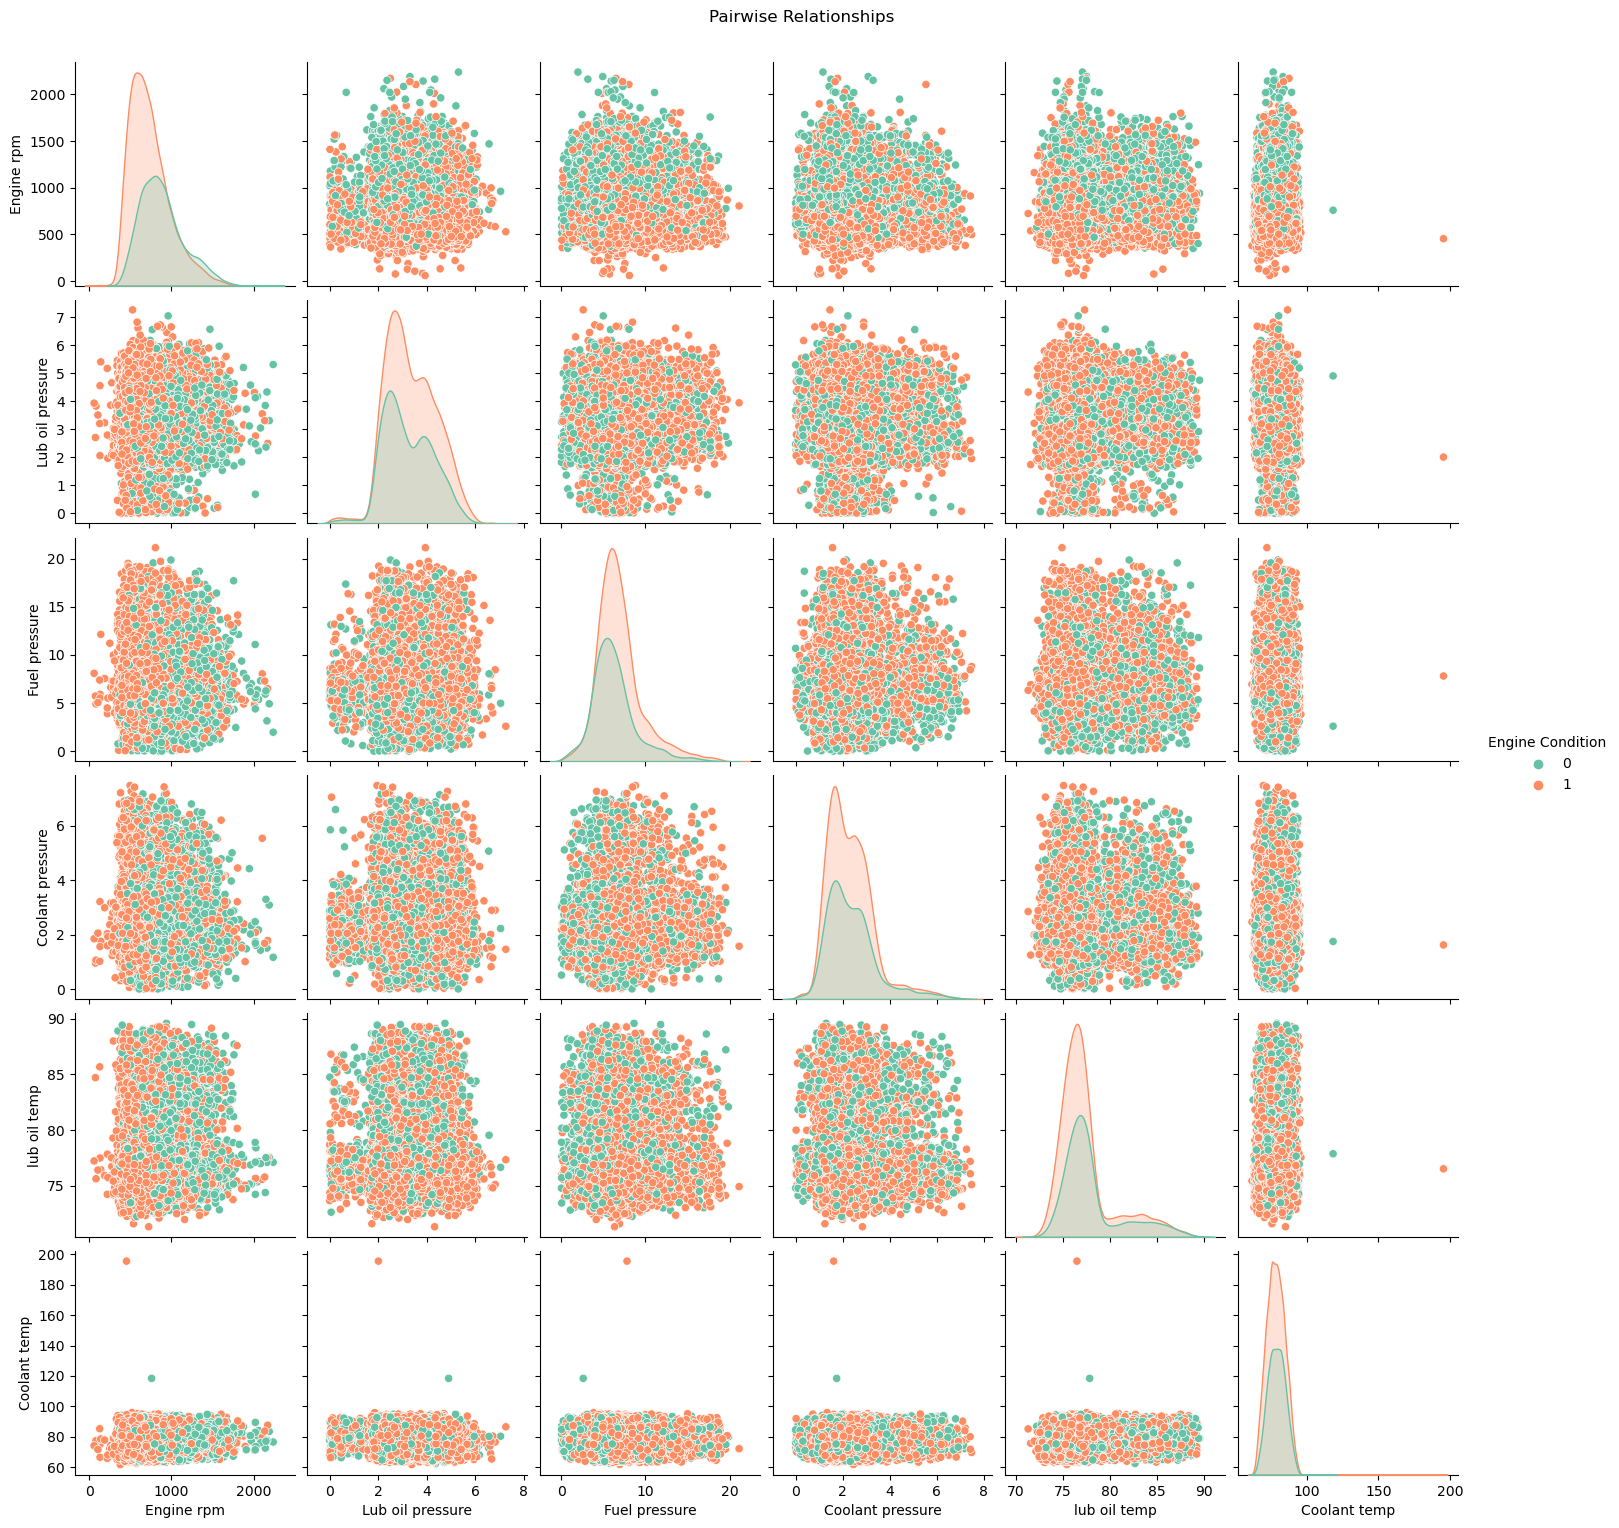

In [8]:
# 3. Pairplot for pairwise relationships between features
data['Engine Condition'] = data['Engine Condition'].astype('category')
sns.pairplot(data, hue="Engine Condition", palette="Set2")
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

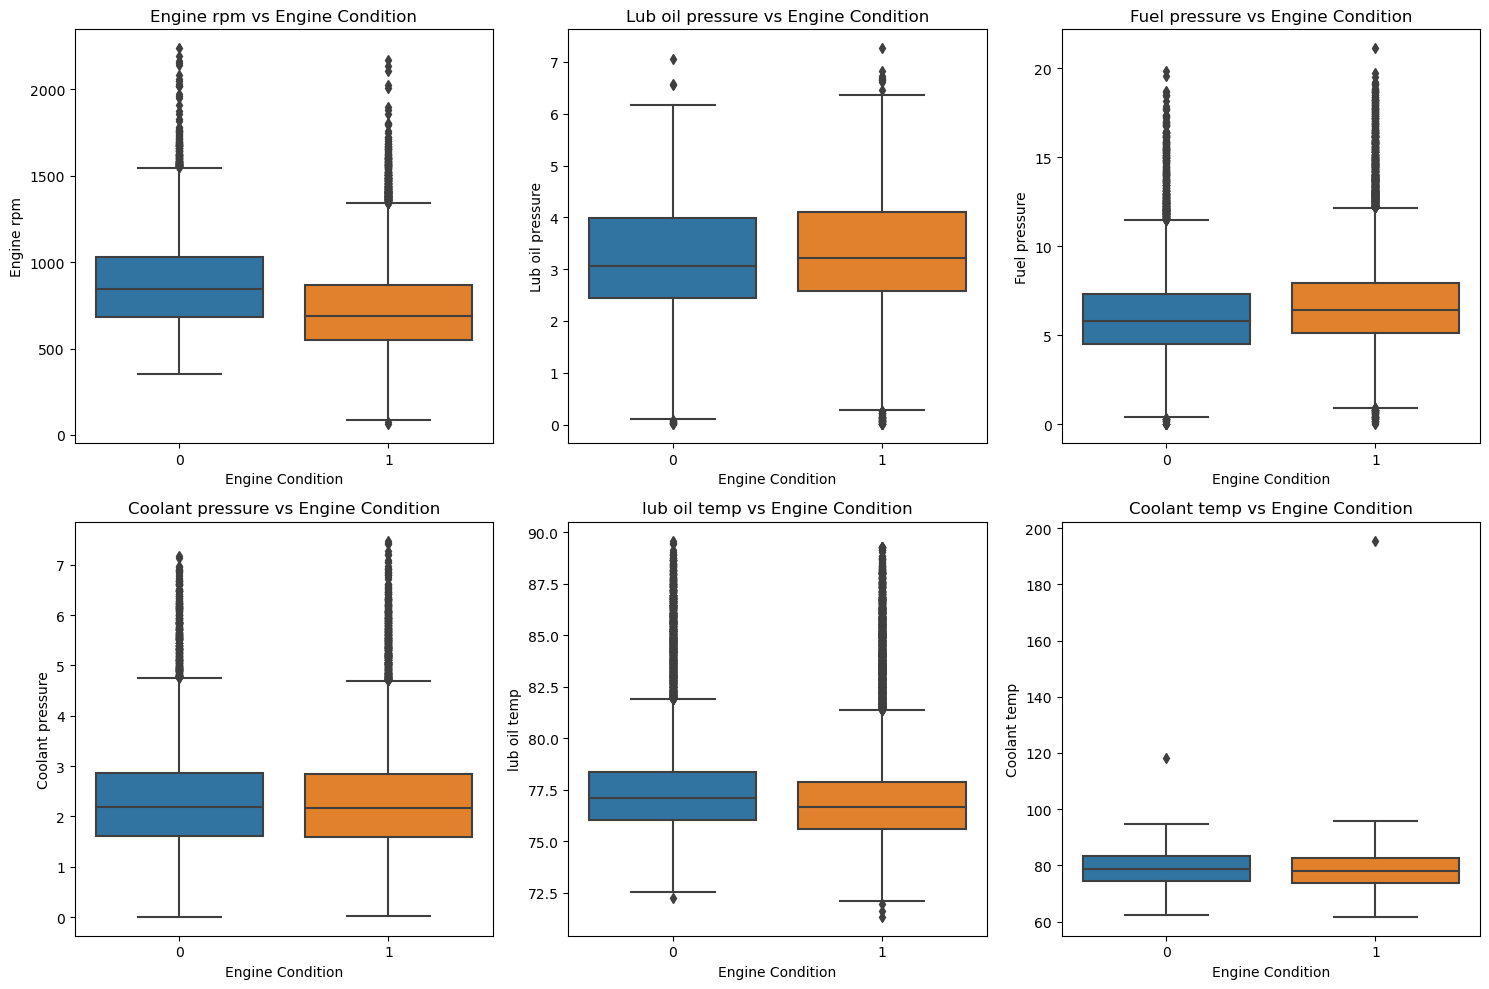

In [9]:
# Visualizing the distribution of features with respect to the target variable
plt.figure(figsize=(15, 10))
features = data.columns[:-1]

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Engine Condition', y=feature, data=data)
    plt.title(f'{feature} vs Engine Condition')

plt.tight_layout()
plt.show()

In [10]:
# Feature scaling
X = data.drop('Engine Condition', axis=1)
y = data['Engine Condition']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [12]:
# 4. Apply SMOTE for balancing the target variable
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [13]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [14]:
y_pred_log_reg = log_reg.predict(X_test)

In [15]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55      2214
           1       0.73      0.68      0.71      3647

    accuracy                           0.64      5861
   macro avg       0.63      0.63      0.63      5861
weighted avg       0.65      0.64      0.65      5861



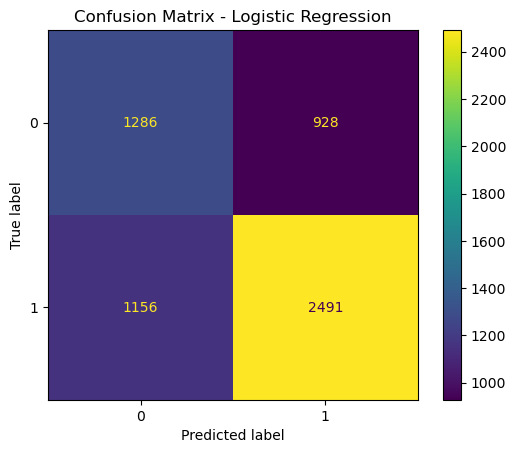

In [18]:
y_pred_log = log_reg.predict(X_test)
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [19]:
# Bagging Classifier
Bagging_Classifier = BaggingClassifier()
Bagging_Classifier.fit(X_train_smote, y_train_smote)

BaggingClassifier()

In [20]:
y_pred_dt = Bagging_Classifier.predict(X_test)

In [21]:
print("Bagging Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

Bagging Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.62      0.54      2214
           1       0.72      0.60      0.65      3647

    accuracy                           0.61      5861
   macro avg       0.60      0.61      0.60      5861
weighted avg       0.63      0.61      0.61      5861



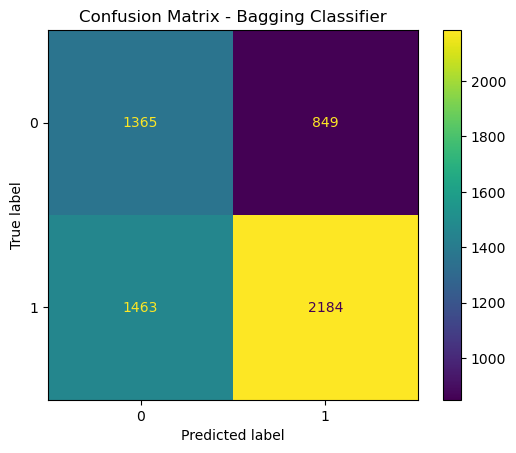

In [23]:
y_pred_bag = Bagging_Classifier.predict(X_test)
cm_bag = confusion_matrix(y_test, y_pred_bag)
disp_bag = ConfusionMatrixDisplay(confusion_matrix=cm_bag)
disp_bag.plot()
plt.title("Confusion Matrix - Bagging Classifier")
plt.show()

In [24]:
# Random Forest Classifier
random_forest = RandomForestClassifier()
random_forest.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [25]:
y_pred_rf = random_forest.predict(X_test)

In [26]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.57      0.54      2214
           1       0.72      0.68      0.70      3647

    accuracy                           0.64      5861
   macro avg       0.62      0.62      0.62      5861
weighted avg       0.64      0.64      0.64      5861



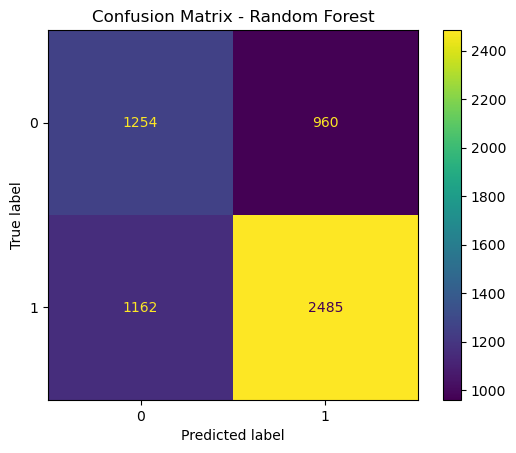

In [27]:
y_pred_rf = random_forest.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [28]:
# Support Vector Machine
svm = SVC()
svm.fit(X_train_smote, y_train_smote)

SVC()

In [29]:
y_pred_svm = svm.predict(X_test)

In [30]:
print("Support Vector Machine Classification Report:")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.66      0.58      2214
           1       0.75      0.62      0.68      3647

    accuracy                           0.64      5861
   macro avg       0.63      0.64      0.63      5861
weighted avg       0.66      0.64      0.64      5861



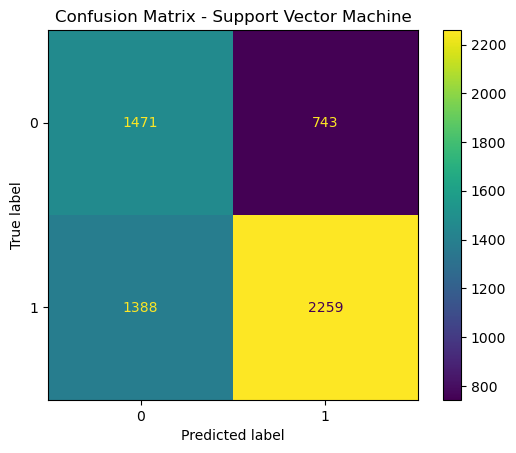

In [31]:
y_pred_svm = svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.title("Confusion Matrix - Support Vector Machine")
plt.show()


In [32]:
# XGBoost
xgboost = XGBClassifier()
xgboost.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [33]:
y_pred_xgb = xgboost.predict(X_test)

In [34]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.58      0.54      2214
           1       0.72      0.65      0.68      3647

    accuracy                           0.63      5861
   macro avg       0.61      0.62      0.61      5861
weighted avg       0.64      0.63      0.63      5861



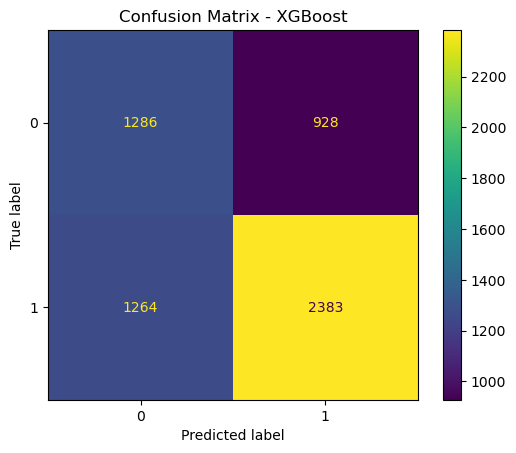

In [35]:
y_pred_xgb = xgboost.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [36]:
# Find the best model based on accuracy
models = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest,
    "Support Vector Machine": svm,
    "XGBoost": xgboost,
    "Bagging Classifier": Bagging_Classifier
}

# Store accuracy scores for all models
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

In [37]:
# Best model
best_model_name = max(results, key=results.get)
best_model_accuracy = results[best_model_name]

# Print the best model and its classification report
print(f"Best Model: {best_model_name} with accuracy: {best_model_accuracy * 100:.2f}%")
print(f"\nClassification Report for {best_model_name}:")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

Best Model: Logistic Regression with accuracy: 64.44%

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55      2214
           1       0.73      0.68      0.71      3647

    accuracy                           0.64      5861
   macro avg       0.63      0.63      0.63      5861
weighted avg       0.65      0.64      0.65      5861



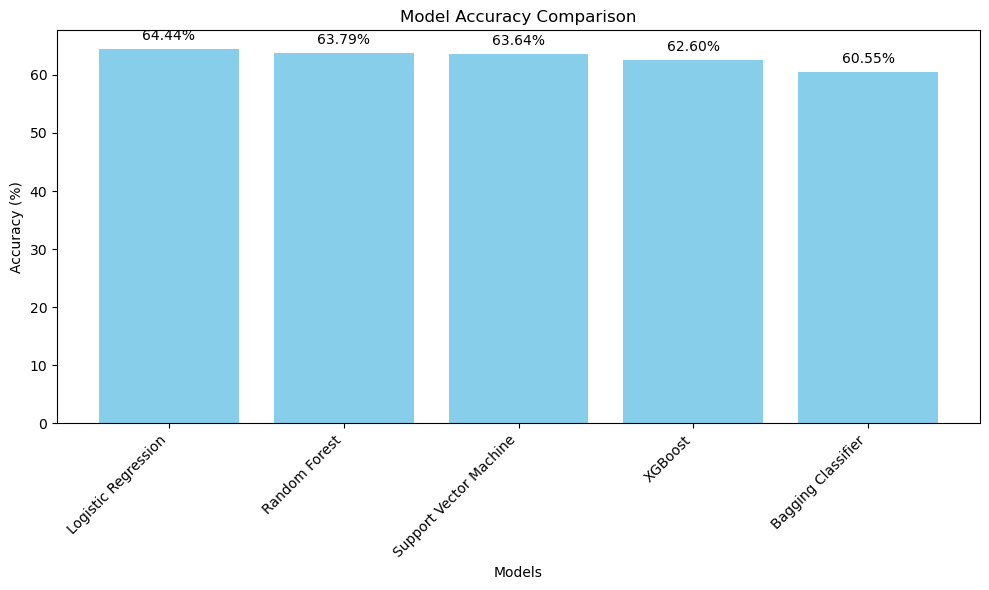

In [38]:
# Plotting accuracy scores for all models
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[name] * 100 for name in model_names]

plt.bar(model_names, accuracies, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()